### Build a DNN using Keras with `RELU` and `ADAM`

In [1]:
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity='all'

#### Load tensorflow

In [2]:
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib
import matplotlib.pyplot as plt
np.random.seed(42)
tf.set_random_seed(42)
tf.__version__
tf.keras.__version__
tf.reset_default_graph()

'1.14.0'

'2.2.4-tf'

#### Collect Fashion mnist data from tf.keras.datasets 

In [3]:
(train_images, train_labels), (test_images, test_labels) = tf.keras.datasets.fashion_mnist.load_data()

In [4]:
train_images.shape

(60000, 28, 28)

In [5]:
train_labels.shape

(60000,)

In [6]:
test_images.shape

(10000, 28, 28)

In [7]:
test_labels.shape

(10000,)

In [8]:
print(test_labels[0:5])

[9 2 1 1 6]


In [9]:
  # Define the text labels
  fashion_mnist_labels = ["T-shirt/top",  # index 0
                          "Trouser",      # index 1
                          "Pullover",     # index 2 
                          "Dress",        # index 3 
                          "Coat",         # index 4
                          "Sandal",       # index 5
                          "Shirt",        # index 6 
                          "Sneaker",      # index 7 
                          "Bag",          # index 8 
                          "Ankle boot"]   # index 9

In [10]:
def plot_images(image_label_tuple, grid_nums):
    plt.figure(figsize=(2*grid_nums, 2*grid_nums))
    for i in range(grid_nums**2):
        plt.subplot(grid_nums, grid_nums, i+1)
        plt.imshow(image_label_tuple[0][i], cmap='gray')
        plt.colorbar()
        plt.xticks([])
        plt.yticks([])
        plt.xlabel(fashion_mnist_labels[image_label_tuple[1][i]])
        plt.grid(False)
    plt.show()    

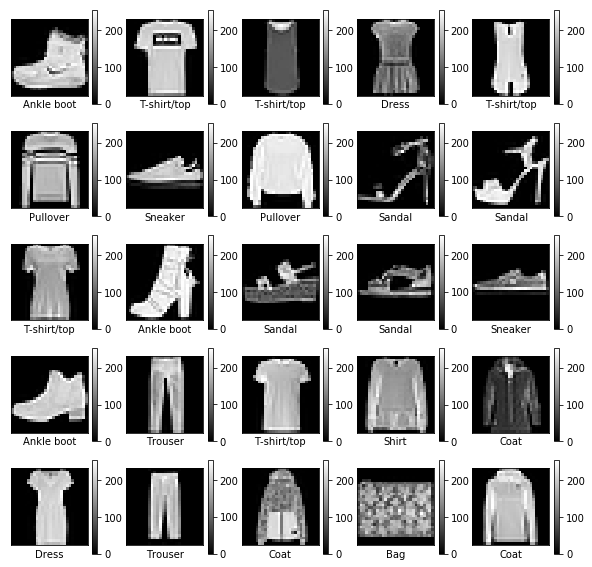

In [11]:
plot_images((train_images, train_labels),5)

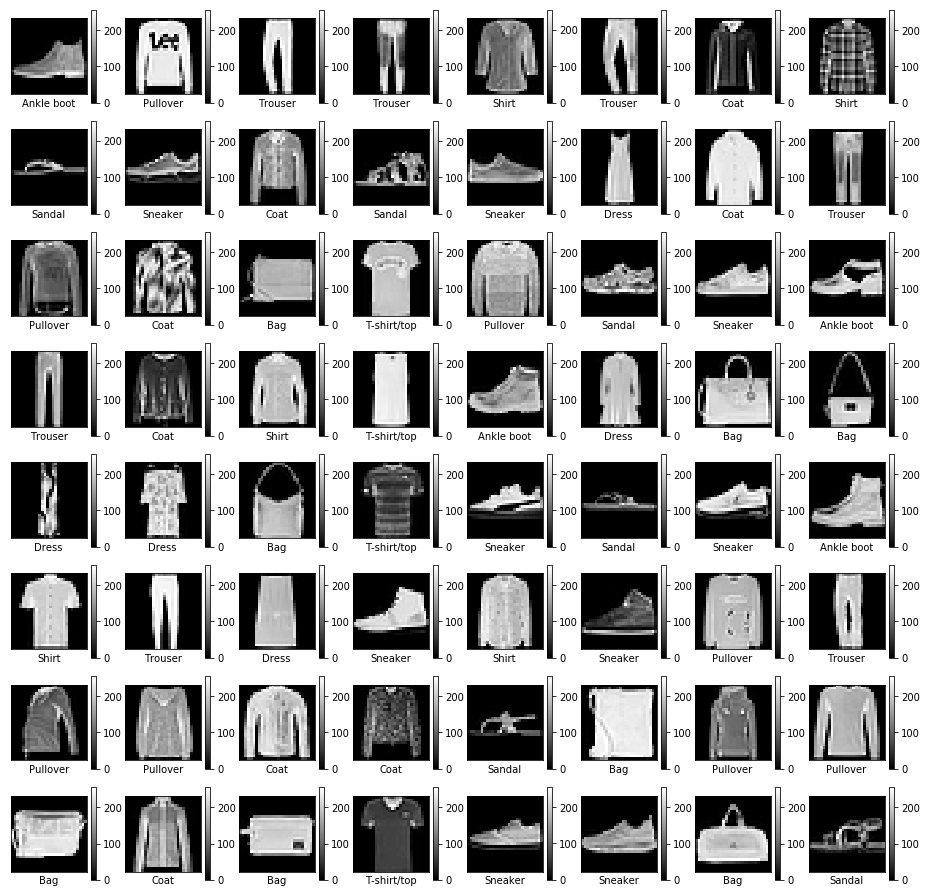

In [12]:
plot_images((test_images, test_labels), 8)

#### Change train and test labels into one-hot vectors

In [13]:
train_labels_one_hot = tf.keras.utils.to_categorical(train_labels)
test_labels_one_hot  = tf.keras.utils.to_categorical(test_labels)

In [14]:
train_labels_one_hot[0:2]

array([[0., 0., 0., 0., 0., 0., 0., 0., 0., 1.],
       [1., 0., 0., 0., 0., 0., 0., 0., 0., 0.]], dtype=float32)

In [15]:
test_labels_one_hot[0:2]

array([[0., 0., 0., 0., 0., 0., 0., 0., 0., 1.],
       [0., 0., 1., 0., 0., 0., 0., 0., 0., 0.]], dtype=float32)

#### Build the Graph

#### Initialize model, reshape & normalize data

In [16]:
tf.keras.backend.clear_session()
# Initialize model, reshape & normalize the data
model = tf.keras.models.Sequential()
# Reshape the data from 2D (28,28) to 3D(28,28, 1)
model.add(tf.keras.layers.Reshape(target_shape=(28,28,1), input_shape=(28,28)))
# Normalize the data
model.add(tf.keras.layers.BatchNormalization())

#### Add two fully connected layers with 200 and 100 neurons respectively with `relu` activations. Add a dropout layer with `p=0.25`

In [17]:
# Flatten the output
model.add(tf.keras.layers.Flatten())

# Add first Dense layer
model.add(tf.keras.layers.Dense(200, activation='relu'))

# Add first Dense layer
model.add(tf.keras.layers.Dense(100, activation='relu'))

# Add Droput layer
model.add(tf.keras.layers.Dropout(rate=0.25))

W0822 13:59:32.631633 12056 deprecation.py:506] From C:\Users\ojhaj\Anaconda3\lib\site-packages\tensorflow\python\ops\init_ops.py:1251: calling VarianceScaling.__init__ (from tensorflow.python.ops.init_ops) with dtype is deprecated and will be removed in a future version.
Instructions for updating:
Call initializer instance with the dtype argument instead of passing it to the constructor


### Add the output layer with a fully connected layer with 10 neurons with `softmax` activation. Use `categorical_crossentropy` loss and `adam` optimizer and train the network. And, report the final validation.

In [18]:
# Add output layer
model.add(tf.keras.layers.Dense(10, activation='softmax', kernel_regularizer=tf.keras.regularizers.l2(0.01)))

In [19]:
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

In [20]:
model.summary()

Model: "sequential"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
reshape (Reshape)            (None, 28, 28, 1)         0         
_________________________________________________________________
batch_normalization (BatchNo (None, 28, 28, 1)         4         
_________________________________________________________________
flatten (Flatten)            (None, 784)               0         
_________________________________________________________________
dense (Dense)                (None, 200)               157000    
_________________________________________________________________
dense_1 (Dense)              (None, 100)               20100     
_________________________________________________________________
dropout (Dropout)            (None, 100)               0         
_________________________________________________________________
dense_2 (Dense)              (None, 10)                1

### Train the model

In [21]:
model.fit(train_images, train_labels_one_hot, batch_size=32, validation_data=(test_images, test_labels_one_hot), shuffle=True, epochs=10)

Train on 60000 samples, validate on 10000 samples
Epoch 1/10
60000/60000 [==============================] - 9s 147us/sample - loss: 0.5544 - acc: 0.8243 - val_loss: 0.4290 - val_acc: 0.8571
Epoch 2/10
60000/60000 [==============================] - 6s 103us/sample - loss: 0.4011 - acc: 0.8629 - val_loss: 0.3935 - val_acc: 0.8637
Epoch 3/10
60000/60000 [==============================] - 6s 102us/sample - loss: 0.3597 - acc: 0.8760 - val_loss: 0.3754 - val_acc: 0.8682
Epoch 4/10
60000/60000 [==============================] - 7s 109us/sample - loss: 0.3355 - acc: 0.8819 - val_loss: 0.3902 - val_acc: 0.8649
Epoch 5/10
60000/60000 [==============================] - 8s 127us/sample - loss: 0.3134 - acc: 0.8896 - val_loss: 0.3745 - val_acc: 0.8751
Epoch 6/10
60000/60000 [==============================] - 7s 110us/sample - loss: 0.2987 - acc: 0.8957 - val_loss: 0.3581 - val_acc: 0.8748
Epoch 7/10
60000/60000 [==============================] - 6s 104us/sample - loss: 0.2860 - acc: 0.8993 - val_l

In [22]:
score = model.evaluate(test_images, test_labels_one_hot)

10000/10000 [==============================] - 1s 57us/sample - loss: 0.3473 - acc: 0.8822


In [23]:
score

[0.34731272255182266, 0.8822]